In [15]:
%pip install brian2 brian2hears librosa numpy scipy matplotlib
%pip install setuptools

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import logging
logging.getLogger('brian2').setLevel(logging.ERROR)

import brian2
brian2.prefs.codegen.target = 'numpy'

from brian2 import Hz, kHz
from brian2hears import Sound, erbspace, Gammatone, Filterbank
from scipy import signal
import librosa
import numpy as np
import matplotlib.pyplot as plt
from math import gcd 
import os
import glob

class EnvelopeFromGammatoneFilterbank(Filterbank):
    """Converts the output of a GammatoneFilterbank to an envelope."""

    def __init__(self, source):
        super().__init__(source)
        self.nchannels = 1

    def buffer_apply(self, input_):
        # 6. take absolute value of the input_
        abs_input = np.abs(input_)
        # 7. power-law compression (exponent 0.6)
        compressed = abs_input ** 0.6
        # 8. linearly combine by summing the subbands
        envelope = np.sum(compressed, axis=1, keepdims=True) 
        return envelope

def process_audio_file(wav_filename, mode='cnn'):
    if mode == 'linear':
        target_sr = 20
        lowcut = 1.0
        highcut = 9.0
    elif mode == 'cnn':
        target_sr = 64
        lowcut = 1.0
        highcut = 32.0
    else:
        raise ValueError("Kies 'linear' of 'cnn' als mode.")
    # 1. LOAD THE AUDIO FILE
    audio_data, sr = librosa.load(wav_filename, sr=None, mono=True)

    # 2. convert the audio file to a brian sound object
    sound = Sound(audio_data.reshape(-1, 1), samplerate=sr*Hz) #audio in 1 kolom (kanaal) door reshape vooor brian


    # 3. 28 center frequencies between 50 Hz and 5 kHz
    cf = erbspace(50*Hz, 5*kHz, 28)

    # 4. create the gammatone filterbank
    gammatone_filterbank = Gammatone(sound, cf)

    # 5. process envelope
    envelope_calcuation = EnvelopeFromGammatoneFilterbank(gammatone_filterbank)
    envelope = envelope_calcuation.process()
    envelope = envelope.flatten() 

    # 6. Bandpass filter instellen (1-32 Hz)
    sos = signal.butter(N=4, Wn=[lowcut, highcut], btype='bandpass', fs=sr, output='sos')
    envelope_filtered = signal.sosfiltfilt(sos, envelope)

    # 7. Downsample de resulterende signalen naar 64Hz
    g = gcd(int(sr), target_sr)
    envelope_downsampled = signal.resample_poly(envelope_filtered, target_sr // g, int(sr) // g)
    
    return envelope_downsampled





Lengte van envelope: 29275 samples.


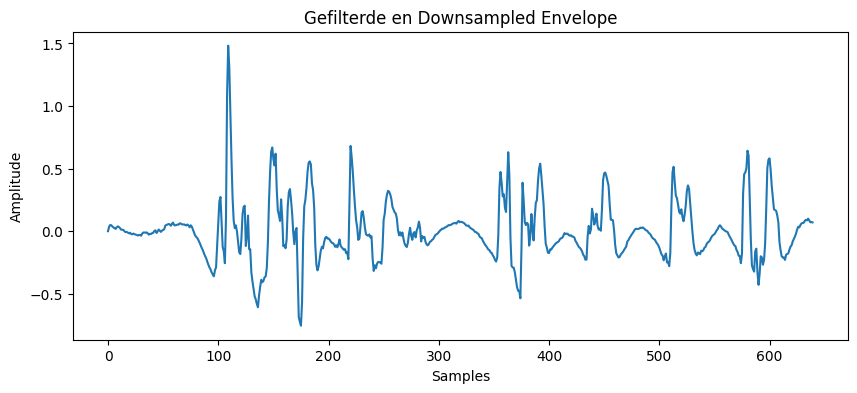

In [17]:
test_audio = "data/stimuli/stimuli_1/audiobook_1_1.wav"


env = process_audio_file(test_audio)
print(f"Lengte van envelope: {len(env)} samples.")
envelope_LR = process_audio_file(test_audio, mode='cnn')    
# Visuele check: plot de eerste 10 seconden (10 * 64 Hz = 640 samples) (voor cnn 64 hz, voor lineair 20)
plt.figure(figsize=(10, 4))
plt.plot(env[:640])
plt.title("Gefilterde en Downsampled Envelope")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [24]:
def process_eeg_file(npz_filename, mode='cnn'):
    
    data = np.load(npz_filename)
    eeg_data = data['eeg']  # Vorm: (116736, 64)
    fs = int(data['fs'])    # 128 Hz
    
    # Handig voor straks: haal direct de paden van de bijbehorende audio op!
    attended_wav = str(data['stimulus_attended'])
    unattended_wav = str(data['stimulus_unattended'])

    if mode == 'linear':
        target_sr = 20
        lowcut = 1.0
        highcut = 9.0
    elif mode == 'cnn':
        target_sr = 64
        lowcut = 1.0
        highcut = 32.0
    else:
        raise ValueError("Kies 'linear' of 'cnn' als mode.")

    # fs is hier de fs van de EEG (128 Hz)
    sos = signal.butter(N=4, Wn=[lowcut, highcut], btype='bandpass', fs=fs, output='sos')
    
    # voeg axis=0 toe, zodat hij filtert over de tijd, niet over de 64 kanalen heen
    eeg_filtered = signal.sosfiltfilt(sos, eeg_data, axis=0)

    # downsample
    g = gcd(fs, target_sr)
    # Ook hier axis=0 toevoegen
    eeg_downsampled = signal.resample_poly(eeg_filtered, target_sr // g, fs // g, axis=0)
    
    
    return eeg_downsampled, attended_wav, unattended_wav

eeg_pad = "data/64 Channel Biosemi unprocessed data - train/sub-01-10/sub-001/sub-001_-_audiobook_1.npz"
eeg_processed, att_audio, unatt_audio = process_eeg_file(eeg_pad, mode='cnn')

print(f"Attended audio file volgens de EEG: {att_audio}")
print(f"Unattended audio file volgens de EEG: {unatt_audio}")

Attended audio file volgens de EEG: audiobook_1.wav
Unattended audio file volgens de EEG: audiobook_5_2.wav


In [25]:
def create_lagged_eeg(eeg_data, num_lags):
    """
    Voegt time-lags toe aan de EEG data.
    eeg_data: numpy array van vorm (n_samples, n_channels)
    num_lags: hoeveel tijdstappen we vooruit willen kijken
    """
    n_samples, n_channels = eeg_data.shape
    
    # Omdat we 'vooruit' in de tijd schuiven, raken we aan het einde 
    # een paar samples kwijt waar geen 'toekomst' meer voor is.
    valid_samples = n_samples - num_lags + 1
    
    # Maak een lege, brede matrix aan: (valid_samples, kanalen * lags)
    lagged_matrix = np.zeros((valid_samples, n_channels * num_lags))
    
    # Vul de matrix per lag
    for lag in range(num_lags):
        start_col = lag * n_channels
        end_col = (lag + 1) * n_channels
        
        # Verschuif de data simpelweg door een ander 'raampje' (slice) te nemen
        lagged_matrix[:, start_col:end_col] = eeg_data[lag : lag + valid_samples, :]
        
    return lagged_matrix

# --- TEST DE FUNCTIE ---
# Laten we doen alsof we een piepkleine EEG file hebben van 100 samples en 64 kanalen
dummy_eeg = np.random.rand(100, 64)
aantal_lags = 5 # (komt overeen met 250ms bij 20Hz)

lagged_result = create_lagged_eeg(dummy_eeg, aantal_lags)

print(f"Originele vorm: {dummy_eeg.shape}")
print(f"Nieuwe vorm na {aantal_lags} lags: {lagged_result.shape}")
# De output zou (96, 320) moeten zijn!

Originele vorm: (100, 64)
Nieuwe vorm na 5 lags: (96, 320)


In [26]:
def calculate_covariance_matrices(lagged_eeg, attended_envelope):
    """
    Berekent de R en r_ms matrices voor één specifieke trial.
    lagged_eeg: de (N, 320) matrix die we net hebben gemaakt
    attended_envelope: de (N,) vector van de juiste audio
    """
    
    # Let op: Soms is de ene array net 1 of 2 samples langer door het afronden 
    # bij downsampling of het time-laggen. We moeten ze exact even lang maken!
    min_length = min(lagged_eeg.shape[0], attended_envelope.shape[0])
    
    M = lagged_eeg[:min_length, :]
    S = attended_envelope[:min_length]
    
    # 1. Bereken de Autocorrelatiematrix R (M transpose keer M)
    # Dit geeft een matrix van (320, 320)
    R = np.dot(M.T, M) #de som van alle producten van de EEG-kanalen met elkaar over de tijd.
    
    # 2. Bereken de Kruiscorrelatievector r_ms (M transpose keer S)
    # Dit geeft een vector van (320,)
    r_ms = np.dot(M.T, S)
    
    return R, r_ms, min_length

# --- TEST DE FUNCTIE MET ONZE DUMMY DATA ---
# We maken een dummy audio-envelope die past bij onze dummy EEG
dummy_audio = np.random.rand(96) 

R_test, rms_test, lengte = calculate_covariance_matrices(lagged_result, dummy_audio)

print(f"Vorm van R: {R_test.shape} (moet 320x320 zijn)")
print(f"Vorm van r_ms: {rms_test.shape} (moet 320 zijn)")

Vorm van R: (320, 320) (moet 320x320 zijn)
Vorm van r_ms: (320,) (moet 320 zijn)


In [27]:

# --- INSTELLINGEN ---
subject_map = "data/64 Channel Biosemi unprocessed data - train/sub-01-10/sub-001/"
stimuli_map = "data/stimuli/" # Pas dit aan als je bestanden in specifieke submappen zitten (zoals stimuli_1)
mode = 'cnn' # Zorgt voor 20 Hz en 1-9 Hz filter
num_lags = 5    # 250 ms bij 20 Hz

# Lijsten om de berekende matrices in op te slaan
R_matrices = []
rms_vectoren = []
alle_trials_info = []

# Zoek alle .npz bestanden van subject 1
eeg_bestanden = glob.glob(os.path.join(subject_map, "*.npz"))

print(f"Gevonden trials voor deze proefpersoon: {len(eeg_bestanden)}")

for i, eeg_pad in enumerate(eeg_bestanden):
    print(f"\n--- Verwerken Trial {i+1}/{len(eeg_bestanden)} ---")
    
    # 1. EEG Preprocessing
    # Gebruik de functie die we eerder hebben gemaakt
    eeg_processed, att_audio_naam, unatt_audio_naam = process_eeg_file(eeg_pad, mode=mode)
    
    # 2. Audio Preprocessing (Attended Audio)
    # Let op: Soms heet het bestand in de EEG 'audiobook_1.wav', maar staat het in
    # de map 'stimuli_1/audiobook_1_1.wav'. Voor nu proberen we de naam direct te plakken.
    # Pas het pad aan als jouw bestandsstructuur net iets anders heet!
    att_audio_pad = os.path.join(stimuli_map, "stimuli_1", att_audio_naam) 
    
    print(f"Zoeken naar audiobestand: {att_audio_pad}")
    try:
        att_envelope = process_audio_file(att_audio_pad, mode=mode)
    except Exception as e:
        print(f"Fout bij laden audio (misschien staat hij in stimuli_2?): {e}")
        continue # Sla deze trial over als de audio niet gevonden wordt
        
    # 3. Time lags toepassen op EEG
    lagged_eeg = create_lagged_eeg(eeg_processed, num_lags)
    
    # 4. R en r_ms berekenen voor deze specifieke trial
    R_trial, rms_trial, lengte = calculate_covariance_matrices(lagged_eeg, att_envelope)
    
    # 5. Opslaan voor de cross-validatie
    R_matrices.append(R_trial)
    rms_vectoren.append(rms_trial)
    
    # Sla ook de onbewerkte data paden op, zodat we straks de test-fase kunnen doen
    alle_trials_info.append({
        'eeg_pad': eeg_pad,
        'att_audio_pad': att_audio_pad,
        'unatt_audio_naam': unatt_audio_naam # We zoeken de unattended audio pas op tijdens de testfase!
    })

print("\nKlaar! Alle trainingsmatrices zijn berekend en opgeslagen.")

Gevonden trials voor deze proefpersoon: 3

--- Verwerken Trial 1/3 ---
Zoeken naar audiobestand: data/stimuli/stimuli_1/audiobook_5_2.wav

--- Verwerken Trial 2/3 ---
Zoeken naar audiobestand: data/stimuli/stimuli_1/audiobook_1.wav

--- Verwerken Trial 3/3 ---
Zoeken naar audiobestand: data/stimuli/stimuli_1/audiobook_5_1.wav

Klaar! Alle trainingsmatrices zijn berekend en opgeslagen.


In [28]:
from scipy.stats import pearsonr


def run_leave_one_out_evaluation(R_matrices, rms_vectoren, trials_info, stimuli_map):
    """
    Voert de Leave-One-Out cross-validatie uit voor een proefpersoon.
    Geeft de uiteindelijke accuracy terug.
    """
    correcte_detecties = 0
    totaal_trials = len(R_matrices)
    
    
    for k in range(totaal_trials):
        # --- TRAINEN ---
        # Sommeer alle data behalve trial k
        R_train = sum([R_matrices[i] for i in range(totaal_trials) if i != k])
        rms_train = sum([rms_vectoren[i] for i in range(totaal_trials) if i != k])
        
        # d = R^-1 * r_ms 
        decoder_d = np.dot(np.linalg.pinv(R_train), rms_train)
        
        # --- TESTEN ---
        test_info = trials_info[k]
        
        # Preprocess test EEG
        eeg_test, _, _ = process_eeg_file(test_info['eeg_pad'], mode='linear')
        lagged_test_eeg = create_lagged_eeg(eeg_test, num_lags=5)
        
        # Preprocess Attended Audio
        att_env_test = process_audio_file(test_info['att_audio_pad'], mode='linear')
        
        # Preprocess Unattended Audio (Let op de mapnaam!)
        unatt_audio_pad = os.path.join(stimuli_map, "stimuli_1", test_info['unatt_audio_naam'])
        unatt_env_test = process_audio_file(unatt_audio_pad, mode='linear')
        
        # Maak alles even lang
        min_len = min(lagged_test_eeg.shape[0], att_env_test.shape[0], unatt_env_test.shape[0])
        
        # Reconstructie: s_hat = d^T * m(t) 
        gereconstrueerde_audio = np.dot(lagged_test_eeg[:min_len, :], decoder_d)
        
        # Bereken correlaties 
        r_attended, _ = pearsonr(gereconstrueerde_audio, att_env_test[:min_len])
        r_unattended, _ = pearsonr(gereconstrueerde_audio, unatt_env_test[:min_len])
        
        # Check of hij het goed had 
        if r_attended > r_unattended:
            print(f" Trial {k+1}:  Correct (Att: {r_attended:.3f} > Unatt: {r_unattended:.3f})")
            correcte_detecties += 1
        else:
            print(f" Trial {k+1}:  Fout   (Att: {r_attended:.3f} <= Unatt: {r_unattended:.3f})")
            
    # Eindscore berekenen
    accuracy = (correcte_detecties / totaal_trials) * 100
    return accuracy

In [29]:
score_subject1 = run_leave_one_out_evaluation(
    R_matrices, 
    rms_vectoren, 
    alle_trials_info, 
    stimuli_map="data/stimuli/"
)

print(f"\n======================================")
print(f"Eindresultaat Subject 001: {score_subject1:.1f}%")
print(f"======================================")

 Trial 1:  Correct (Att: 0.013 > Unatt: 0.011)
 Trial 2:  Correct (Att: 0.016 > Unatt: 0.001)
 Trial 3:  Correct (Att: 0.018 > Unatt: 0.001)

Eindresultaat Subject 001: 100.0%


In [36]:
import os
import glob
import numpy as np

# --- INSTELLINGEN ---
bron_map = "data/stimuli/"
# De doelmap kiest nu automatisch de submap op basis van de mode (cnn of linear)
mode = 'cnn' 

# 🟢 PAS DIT NUMMER AAN (1 t/m 5) VOOR ELKE RUN 🟢
map_nummer = 5  
huidige_stimuli_map = f"stimuli_{map_nummer}"

# Paden opbouwen volgens de nieuwe mappenstructuur
# Dit maakt bijv: data/preprocessed/audio/cnn/stimuli_1/
doel_basis = os.path.join("data/preprocessed/audio/", mode)
bron_submap = os.path.join(bron_map, huidige_stimuli_map)
doel_submap = os.path.join(doel_basis, huidige_stimuli_map)

# Maak de mappen aan als ze nog niet bestaan
os.makedirs(doel_submap, exist_ok=True)

print(f"--- 🎧 START AUDIO PREPROCESSING ---")
print(f"Mode:      {mode.upper()}")
print(f"Bron:      {bron_submap}")
print(f"Doel:      {doel_submap}")
print(f"---------------------------------------")

# Zoek alle .wav bestanden
wav_bestanden = sorted(glob.glob(os.path.join(bron_submap, "*.wav")))
print(f"Aantal gevonden bestanden: {len(wav_bestanden)}")

for wav_pad in wav_bestanden:
    # Haal de basisnaam op (bijv. 'audio01')
    basisnaam = os.path.basename(wav_pad).replace('.wav', '')
    
    # Voeg suffix toe als we in CNN mode zitten
    if mode == 'cnn':
        nieuwe_naam = f"{basisnaam}_cnn.npy"
    else:
        nieuwe_naam = f"{basisnaam}.npy"
        
    opsla_pad = os.path.join(doel_submap, nieuwe_naam)
    
    # Check of bestand al bestaat
    if os.path.exists(opsla_pad):
        print(f"⏩ Skippen: {nieuwe_naam}")
    else:
        print(f"⚙️ Verwerken: {nieuwe_naam} ...")
        try:
            # Aanroep van de externe functie (brian2/librosa mix)
            # Zorg dat 'process_audio_file' gedefinieerd is in je notebook!
            resultaat = process_audio_file(wav_pad, mode=mode)
            
            # Opslaan als numpy bestand
            np.save(opsla_pad, resultaat)
            print(f"   ✅ Opgeslagen!")
        except Exception as e:
            print(f"   ❌ Fout bij {nieuwe_naam}: {e}")

print(f"\n🎉 Klaar! De bestanden staan in: {doel_submap}")

--- 🎧 START AUDIO PREPROCESSING ---
Mode:      CNN
Bron:      data/stimuli/stimuli_5
Doel:      data/preprocessed/audio/cnn/stimuli_5
---------------------------------------
Aantal gevonden bestanden: 12
⚙️ Verwerken: podcast_26_cnn.npy ...
   ✅ Opgeslagen!
⚙️ Verwerken: podcast_27_cnn.npy ...
   ✅ Opgeslagen!
⚙️ Verwerken: podcast_28_cnn.npy ...
   ✅ Opgeslagen!
⚙️ Verwerken: podcast_29_cnn.npy ...
   ✅ Opgeslagen!
⚙️ Verwerken: podcast_30_cnn.npy ...
   ✅ Opgeslagen!
⚙️ Verwerken: podcast_31_cnn.npy ...
   ✅ Opgeslagen!
⚙️ Verwerken: podcast_32_cnn.npy ...
   ✅ Opgeslagen!
⚙️ Verwerken: podcast_33_cnn.npy ...
   ✅ Opgeslagen!
⚙️ Verwerken: podcast_34_cnn.npy ...
   ✅ Opgeslagen!
⚙️ Verwerken: podcast_35_cnn.npy ...
   ✅ Opgeslagen!
⚙️ Verwerken: podcast_36_cnn.npy ...
   ✅ Opgeslagen!
⚙️ Verwerken: podcast_37_cnn.npy ...
   ✅ Opgeslagen!

🎉 Klaar! De bestanden staan in: data/preprocessed/audio/cnn/stimuli_5
